# Home Credit Default Risk — Feature Engineering

## Notebook Overview

This notebook creates a clean, interpretable, and model-ready feature set for the Home Credit Default Risk problem.

The feature engineering decisions are based on the completed univariate, multivariate, temporal, structural, and financial relationship analyses. The purpose of this notebook is not to repeat those analyses. Its purpose is to implement the final evidence-based decisions using simple, readable, and reproducible code.

The notebook begins with the integrated applicant-level training and testing datasets. Existing features will be cleaned where necessary, and new features will be created from applicant information, financial capacity, repayment behaviour, credit history, temporal change, and cross-source financial stress.

The main workflow is:

1. Load the integrated training and testing datasets.
2. Load only the essential EDA decision files.
3. Remove exact and deterministic duplicate features.
4. Correct known invalid values and sentinel values.
5. Standardise reviewed categorical values and data types.
6. Create source-history and missingness-summary features.
7. Create zero-activity and exposure indicators.
8. Engineer application-level affordability and household-capacity features.
9. Engineer applicant stability, external-score, enquiry, and property features.
10. Engineer Bureau, Instalment, Credit Card, POS Cash, and Previous Application features.
11. Create exposure-normalised behavioural ratios.
12. Create validated temporal-change features.
13. Create cross-source coverage, stress, consensus, and disagreement features.
14. Add a small set of validated interaction and cyclical features.
15. Prepare main, lean, compact, and fairness-comparison feature lists.
16. Validate train-test alignment and save the final feature-engineered datasets.

## Design Principles

- The notebook follows a direct, step-by-step workflow.
- Simple tasks are implemented with simple code.
- Classes and large software-style frameworks are not used.
- Small helper functions are used only when they reduce repetition.
- Every engineered feature has a clear financial, behavioural, temporal, or structural meaning.
- Feature creation is identical for the training and testing datasets.
- The target and applicant identifier are never used to create predictor features.
- Exact and deterministic duplicates may be removed, but near-redundant features are handled through separate feature lists.
- Missing values are interpreted carefully because missingness may represent absent financial history, non-applicability, or data-quality issues.
- Zero values are not treated uniformly because zero may represent no activity, no adverse event, no exposure, or unavailable history.
- Large-scale automatic interaction generation is avoided.
- Only validated and interpretable interaction features are created.
- Model-specific preprocessing is intentionally excluded from this notebook.

## Modelling Boundary

This notebook does not perform model training, cross-validation, target encoding, supervised binning, scaling, PCA fitting, or model-based feature selection.

The following operations will be completed inside the model-training notebook and within the appropriate training folds:

- Missing-value imputation
- Scaling
- One-hot encoding
- Target encoding
- Weight-of-evidence encoding
- Yeo-Johnson transformation
- Quantile transformation
- Supervised binning
- PCA experiments
- Model-based feature selection
- Model training and blending

## Checkpoint Strategy

Large processing blocks are saved as parquet checkpoints. These checkpoints allow the notebook to resume after interruption without repeating all previous feature engineering steps.

The main checkpoints will represent:

- Cleaned integrated data
- Application-level engineered data
- Behavioural-source engineered data
- Final feature-engineered data

## Final Outputs

The notebook will create:

- Final feature-engineered training data
- Final feature-engineered testing data
- Engineered feature list
- Removed feature list
- Main feature list
- Lean feature list
- Compact explainable feature list
- Fairness exclusion list
- Feature engineering summary

The final datasets will be used as the direct inputs for the separate model-training notebook.

# Step 0 — Setup and Data Loading

This step imports the required libraries, defines the project paths, creates the output folders, and loads the integrated training and testing datasets.

Only a small number of structural checks are performed to confirm that the target, applicant identifier, dataset shapes, and predictor columns are correct.

No feature is created, removed, transformed, imputed, or encoded in this step.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 180)

PROJECT_ROOT = Path(r"C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk")

TRAIN_PATH = PROJECT_ROOT / "Data" / "Processed" / "home_credit_train_integrated.parquet"
TEST_PATH = PROJECT_ROOT / "Data" / "Processed" / "home_credit_test_integrated.parquet"

OUTPUT_DIR = PROJECT_ROOT / "Feature_engineering"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

ID_COLUMN = "SK_ID_CURR"
TARGET_COLUMN = "TARGET"
RANDOM_STATE = 42

print("Project paths are ready.")
print(f"Project root: {PROJECT_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")

Project paths are ready.
Project root: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk
Output directory: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Feature_engineering


In [3]:
train = pd.read_parquet(TRAIN_PATH)
test = pd.read_parquet(TEST_PATH)

train_predictors = [column for column in train.columns if column not in [ID_COLUMN, TARGET_COLUMN]]
test_predictors = [column for column in test.columns if column != ID_COLUMN]

assert TARGET_COLUMN in train.columns, "TARGET is missing from the training dataset."
assert TARGET_COLUMN not in test.columns, "TARGET must not exist in the testing dataset."
assert ID_COLUMN in train.columns, "SK_ID_CURR is missing from the training dataset."
assert ID_COLUMN in test.columns, "SK_ID_CURR is missing from the testing dataset."
assert train[ID_COLUMN].is_unique, "Training applicant identifiers are not unique."
assert test[ID_COLUMN].is_unique, "Testing applicant identifiers are not unique."
assert set(train_predictors) == set(test_predictors), "Training and testing predictor columns do not match."

test = test[[ID_COLUMN] + train_predictors]

print(f"Training shape: {train.shape}")
print(f"Testing shape: {test.shape}")
print(f"Predictor count: {len(train_predictors)}")
print(f"Target default rate: {train[TARGET_COLUMN].mean():.4%}")
print(f"Training memory: {train.memory_usage(deep=True).sum() / (1024 ** 3):.3f} GB")
print(f"Testing memory: {test.memory_usage(deep=True).sum() / (1024 ** 3):.3f} GB")
print("Training and testing predictors are aligned.")

Training shape: (307511, 2568)
Testing shape: (48744, 2567)
Predictor count: 2566
Target default rate: 8.0729%
Training memory: 2.892 GB
Testing memory: 0.458 GB
Training and testing predictors are aligned.


### Basic Dataset Overview

,dataset,rows,columns,predictors,memory_gb
0,Training,307511,2568,2566,2.892286
1,Testing,48744,2567,2566,0.458426


,target,applicant_count,percentage
0,0,282686,91.927118
1,1,24825,8.072882


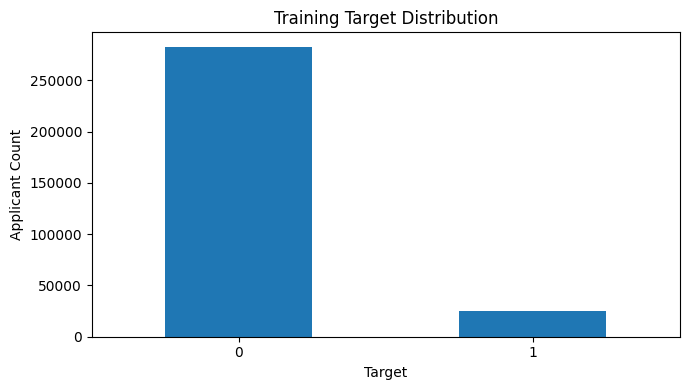

STEP 0 COMPLETE
The integrated datasets were loaded successfully.
No feature was created, removed, transformed, imputed, or encoded.


In [4]:
dataset_overview = pd.DataFrame({
    "dataset": ["Training", "Testing"],
    "rows": [train.shape[0], test.shape[0]],
    "columns": [train.shape[1], test.shape[1]],
    "predictors": [len(train_predictors), len(test_predictors)],
    "memory_gb": [
        train.memory_usage(deep=True).sum() / (1024 ** 3),
        test.memory_usage(deep=True).sum() / (1024 ** 3)
    ]
})

display(dataset_overview)

target_distribution = train[TARGET_COLUMN].value_counts().sort_index().rename_axis("target").reset_index(name="applicant_count")
target_distribution["percentage"] = target_distribution["applicant_count"] / len(train) * 100

display(target_distribution)

plt.figure(figsize=(7, 4))
train[TARGET_COLUMN].value_counts().sort_index().plot(kind="bar")
plt.title("Training Target Distribution")
plt.xlabel("Target")
plt.ylabel("Applicant Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("=" * 80)
print("STEP 0 COMPLETE")
print("The integrated datasets were loaded successfully.")
print("No feature was created, removed, transformed, imputed, or encoded.")
print("=" * 80)

# Step 1 — Load Essential EDA Evidence

This step loads the essential evidence and decision files created during the completed univariate, multivariate, structural, nonlinear, and temporal analyses.

The files are inspected directly so that their exact columns and structures are visible before any feature-engineering decision is implemented.

The univariate master provides feature categories, missingness evidence, transformation reviews, sentinel information, and manual decisions. The multivariate files provide final feature roles, structural identities, redundancy decisions, nonlinear target shapes, and temporal evidence.

No evidence tables are merged in this step. No feature is created, removed, transformed, imputed, or encoded.

In [5]:
UNIVARIATE_PATH = PROJECT_ROOT / "Notebook" / "Eda_report" / "Final_Univariate" / "master_file_univariate.csv"

STEP7_DIR = PROJECT_ROOT / "Notebook" / "relationship_outputs" / "Step_7_Final_Multivariate_Completion" / "tables"
STEP6_DIR = PROJECT_ROOT / "Notebook" / "relationship_outputs" / "Step_6_Global_Feature_Architecture" / "tables"
TEMPORAL_DIR = PROJECT_ROOT / "Notebook" / "Relationship_report" / "Tables" / "Step_5_Temporal_Financial_States"

FINAL_MULTIVARIATE_PATH = STEP7_DIR / "final_multivariate_feature_registry.parquet"
FINAL_DECISION_PATH = STEP7_DIR / "final_feature_decision_register.parquet"
NONLINEAR_PATH = STEP7_DIR / "univariate_nonlinear_geometry.parquet"
FEATURE_IDENTITY_PATH = STEP6_DIR / "6.03_feature_identity_and_lineage_registry.parquet"
STRUCTURAL_ROLE_PATH = STEP6_DIR / "6.09_feature_role_register.parquet"
TEMPORAL_FEATURE_PATH = TEMPORAL_DIR / "5.1_temporal_feature_registry.csv"

evidence_paths = {
    "univariate_master": UNIVARIATE_PATH,
    "final_multivariate": FINAL_MULTIVARIATE_PATH,
    "final_decision": FINAL_DECISION_PATH,
    "nonlinear_geometry": NONLINEAR_PATH,
    "feature_identity": FEATURE_IDENTITY_PATH,
    "structural_role": STRUCTURAL_ROLE_PATH,
    "temporal_features": TEMPORAL_FEATURE_PATH
}

missing_files = [f"{name}: {path}" for name, path in evidence_paths.items() if not path.exists()]

if missing_files:
    raise FileNotFoundError("Missing evidence files:\n" + "\n".join(missing_files))

univariate_master = pd.read_csv(UNIVARIATE_PATH, low_memory=False)
final_multivariate = pd.read_parquet(FINAL_MULTIVARIATE_PATH)
final_decision = pd.read_parquet(FINAL_DECISION_PATH)
nonlinear_geometry = pd.read_parquet(NONLINEAR_PATH)
feature_identity = pd.read_parquet(FEATURE_IDENTITY_PATH)
structural_role = pd.read_parquet(STRUCTURAL_ROLE_PATH)
temporal_features = pd.read_csv(TEMPORAL_FEATURE_PATH, low_memory=False)

print("Essential EDA evidence files loaded successfully.")

Essential EDA evidence files loaded successfully.


In [6]:
evidence_tables = {
    "Univariate Master": univariate_master,
    "Final Multivariate Registry": final_multivariate,
    "Final Feature Decision Register": final_decision,
    "Nonlinear Geometry": nonlinear_geometry,
    "Feature Identity and Lineage": feature_identity,
    "Structural Feature Roles": structural_role,
    "Temporal Feature Registry": temporal_features
}

evidence_summary = pd.DataFrame([
    {
        "evidence": name,
        "rows": table.shape[0],
        "columns": table.shape[1],
        "memory_mb": table.memory_usage(deep=True).sum() / (1024 ** 2)
    }
    for name, table in evidence_tables.items()
])

display(evidence_summary)

for name, table in evidence_tables.items():
    print("=" * 100)
    print(name)
    print(f"Shape: {table.shape}")
    print(f"First 40 columns: {table.columns[:40].tolist()}")
    display(table.head(2))

print("=" * 100)
print("STEP 1 COMPLETE")
print("The essential EDA evidence files were loaded and inspected.")
print("No evidence tables were merged and no feature-engineering decision was applied.")
print("=" * 100)

,evidence,rows,columns,memory_mb
0,Univariate Master,2568,627,42.341532
1,Final Multivariate Registry,2566,56,3.865561
2,Final Feature Decision Register,2566,13,1.013150
3,Nonlinear Geometry,2566,15,0.911345
4,Feature Identity and Lineage,2566,24,2.314581
5,Structural Feature Roles,2566,13,1.075263
6,Temporal Feature Registry,11,15,0.012457


Univariate Master
Shape: (2568, 627)
First 40 columns: ['feature', 'master_feature_category', 'master_feature_family', 'master_dtype_semantic', 'master_model_role', 'master_final_univariate_decision', 'master_drop_now', 'master_next_stage', 'master_feature_engineering_status', 'master_decision_confidence_from_univariate_only', 'master_problem_flags', 'master_univariate_problem_and_route_summary', 'master_flag_high_missing', 'master_flag_extreme_missing', 'master_flag_large_missing_gap', 'master_flag_high_numeric_skew', 'master_flag_high_numeric_outlier', 'master_flag_zero_heavy', 'master_flag_rare_binary_or_near_constant', 'master_flag_rare_nominal_mass', 'master_flag_categorical_shift', 'master_flag_special_case', 'master_flag_manual_reviewed', 'final_univariate_feature_category', 'final_univariate_model_feature_role', 'final_univariate_universal_role', 'final_univariate_universal_dtype_train', 'final_univariate_universal_dtype_test', 'final_univariate_universal_missing_pct_train', 'f

,feature,master_feature_category,master_feature_family,master_dtype_semantic,master_model_role,master_final_univariate_decision,master_drop_now,master_next_stage,master_feature_engineering_status,master_decision_confidence_from_univariate_only,master_problem_flags,master_univariate_problem_and_route_summary,master_flag_high_missing,master_flag_extreme_missing,master_flag_large_missing_gap,master_flag_high_numeric_skew,master_flag_high_numeric_outlier,master_flag_zero_heavy,master_flag_rare_binary_or_near_constant,master_flag_rare_nominal_mass,master_flag_categorical_shift,master_flag_special_case,master_flag_manual_reviewed,final_univariate_feature_category,final_univariate_model_feature_role,final_univariate_universal_role,final_univariate_universal_dtype_train,final_univariate_universal_dtype_test,final_univariate_universal_missing_pct_train,final_univariate_universal_missing_pct_test,final_univariate_universal_missing_gap_pct,final_univariate_universal_n_unique_train,final_univariate_universal_n_unique_test,final_univariate_universal_basic_review_flag,final_univariate_universal_basic_review_reason,final_univariate_numeric_numeric_family,final_univariate_numeric_missing_band,final_univariate_numeric_skew_band,final_univariate_numeric_zero_band,final_univariate_numeric_outlier_band,final_univariate_numeric_section_review_flag,final_univariate_numeric_section_review_reason,final_univariate_binary_categorical_family,final_univariate_binary_missing_pct_train,final_univariate_binary_n_unique_train,final_univariate_binary_zero_pct_train,final_univariate_binary_one_pct_train,final_univariate_binary_one_pct_gap,final_univariate_binary_constant_train,final_univariate_binary_constant_test,...,ordinal_temporal_uppercase_level_count,ordinal_temporal_lowercase_level_count,ordinal_temporal_sample_levels,ordinal_temporal_top_levels_train,ordinal_temporal_special_numeric_level_present,ordinal_temporal_test_only_special_level_present,ordinal_temporal_expected_order_note,ordinal_temporal_missing_route,ordinal_temporal_cardinality_route,ordinal_temporal_rare_level_route,ordinal_temporal_dominance_route,ordinal_temporal_level_support_route,ordinal_temporal_distribution_shift_route,ordinal_temporal_order_support_route,ordinal_temporal_possible_encoding_route,ordinal_temporal_route_modifiers,ordinal_temporal_risk_score,ordinal_temporal_risk_level,ordinal_temporal_manual_check_needed,ordinal_temporal_manual_check_reason,ordinal_temporal_statistical_decision_summary,binary_manual_manual_decision_status,binary_manual_final_encoding_decision,binary_manual_final_missing_handling_decision,binary_manual_final_validation_decision,binary_manual_manual_risk_level,binary_manual_manual_check_needed,binary_manual_manual_check_reason,binary_manual_drop_now,binary_manual_next_stage_use,nominal_manual_manual_encoding_decision,nominal_manual_manual_risk_level,nominal_manual_manual_review_needed,nominal_manual_manual_decision_reason,nominal_manual_next_step_use,nominal_manual_drop_now,ordinal_manual_manual_decision_status,ordinal_manual_final_encoding_decision,ordinal_manual_final_order_or_mapping,ordinal_manual_special_handling_decision,ordinal_manual_manual_risk_level,ordinal_manual_manual_check_needed,ordinal_manual_manual_check_reason,ordinal_manual_drop_now,ordinal_manual_next_stage_use,special_special_case_type,special_special_case_reason,special_special_next_action,special_special_validation_stage,special_special_drop_now
0,AMT_ANNUITY,continuous_amount_numeric,amount_value,numeric,candidate_predictor,standard_candidate_for_next_stage,no,relationship_and_multivariate_analysis,wait_for_relationship_and_multivariate_decision,low_to_medium_standard,standard_profile,standard_univariate_profile || P3_normal_type_specific_eda || route_to_continuous_numeric_eda || continuous_numeric_...,0,0,0,0,0,0,0,0,0,0,0,continuous_amount_numeric,candidate_predictor,feature,float32,float32,0.003902,0.049237,0.045335,13672,7491.0,False,NaN,continuous,low,high,none,moderate,0.0,

Final Multivariate Registry
Shape: (2566, 56)
First 40 columns: ['feature', 'feature_index', 'source', 'declared_category', 'empirical_category', 'validated_category', 'train_dtype', 'test_dtype', 'train_missing_rate', 'test_missing_rate', 'missing_rate_drift', 'exact_cardinality_if_required', 'time_window', 'lineage_base', 'inner_aggregation', 'outer_aggregation', 'category_disagreement', 'target_correlation', 'absolute_target_information', 'present_default_rate', 'missing_default_rate', 'missingness_default_rate_gap', 'community_id', 'community_order', 'maximum_stable_dependency', 'strongest_partner', 'uniqueness_score', 'relationship_stability_score', 'cross_source_bridge_count', 'representative_suitability', 'provisional_feature_role', 'redundancy_status', 'analytical_role', 'generic_lineage_warning', 'confirmation_mutual_information', 'risk_range', 'shape_label', 'shape_agreement', 'max_interaction_gain', 'interaction_pair_count']


,feature,feature_index,source,declared_category,empirical_category,validated_category,train_dtype,test_dtype,train_missing_rate,test_missing_rate,missing_rate_drift,exact_cardinality_if_required,time_window,lineage_base,inner_aggregation,outer_aggregation,category_disagreement,target_correlation,absolute_target_information,present_default_rate,missing_default_rate,missingness_default_rate_gap,community_id,community_order,maximum_stable_dependency,strongest_partner,uniqueness_score,relationship_stability_score,cross_source_bridge_count,representative_suitability,provisional_feature_role,redundancy_status,analytical_role,generic_lineage_warning,confirmation_mutual_information,risk_range,shape_label,shape_agreement,max_interaction_gain,interaction_pair_count,max_absolute_pca_loading,pca_component_count_above_010,exact_duplicate_flag,deterministic_transform_duplicate_flag,nonlinear_interaction_driver_flag,core_latent_driver_flag,missingness_signal_flag,temporal_contrast_flag,final_primary_role,evidence_tags,retain_for_modelling,retain_for_interpretation,retain_for_interaction,retain_missing_indicator,candidate_for_removal,manual_review_required
0,NAME_CONTRACT_TYPE,0,Current application,categorical_binary,categorical_string,categorical_binary,category,category,0.0,0.0,0.0,2.0,Lifetime or non-temporal,name_contract_type,none,none,NONE,0.030894,0.030894,0.080729,NaN,NaN,5,17,0.099193,FLAG_DOCUMENT_3,0.900807,0.894073,0,0.693416,PRIMARY_REPRESENTATIVE,UNRESOLVED,PRIMARY_REPRESENTATIVE,False,0.000595,0.027910,MISSINGNESS_DOMINATED,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,CORE_RAW_REPRESENTATIVE,COMMUNITY_REPRESENTATIVE | MISSINGNESS_DOMINATED,True,True,False,False,False,False
1,CODE_GENDER,1,Current application,categorical_nominal,categorical_string,categorical_nominal,category,category,0.0,0.0,0.0,3.0,Lifetime or non-temporal,code_gender,none,none,NONE,-0.054690,0.054690,0.080729,NaN,NaN,36,55,0.316716,FLAG_OWN_CAR,0.683284,0.984071,0,0.741392,PRIMARY_REPRESENTATIVE,UNRESOLVED,PRIMARY_REPRESENTATIVE,False,0.001440,0.031475,THRESHOLD_EFFECT,0.999999,NaN,NaN,NaN,NaN,False,False,False,False,False,False,CORE_RAW_REPRESENTATIVE,COMMUNITY_REPRESENTATIVE | THRESHOLD_EFFECT,True,True,False,False,False,False


...

Structural Feature Roles
Shape: (2566, 13)
First 40 columns: ['feature', 'feature_index', 'source', 'validated_category', 'community_id', 'maximum_stable_dependency', 'strongest_partner', 'uniqueness_score', 'relationship_stability_score', 'cross_source_bridge_count', 'absolute_target_information', 'representative_suitability', 'provisional_feature_role']


,feature,feature_index,source,validated_category,community_id,maximum_stable_dependency,strongest_partner,uniqueness_score,relationship_stability_score,cross_source_bridge_count,absolute_target_information,representative_suitability,provisional_feature_role
0,pos_status_canceled_count_sum,721,POS cash,binary_flag,1,0.997887,pos_status_canceled_count_max,0.002113,0.964655,0,0.002011,0.515258,PRIMARY_REPRESENTATIVE
1,pos_status_canceled_count_max,723,POS cash,binary_flag,1,0.997887,pos_status_canceled_count_sum,0.002113,0.964655,0,0.002011,0.515258,COMPLEMENTARY_REPRESENTATIVE


Temporal Feature Registry
Shape: (11, 15)
First 40 columns: ['signal', 'label', 'mechanism', 'source', 'weight', 'statistic_type', 'recent_window', 'intermediate_window', 'historical_window', 'numerator_lifetime', 'denominator_lifetime', 'numerator_recent', 'denominator_recent', 'numerator_24m', 'denominator_24m']


,signal,label,mechanism,source,weight,statistic_type,recent_window,intermediate_window,historical_window,numerator_lifetime,denominator_lifetime,numerator_recent,denominator_recent,numerator_24m,denominator_24m
0,installment_late_rate,Installment late-payment rate,repayment_deterioration,Installments,1.25,rate,0–6 months,7–24 months,>24 months,inst_is_late_count_sum,inst_payment_row_count_sum,inst_recent_6m_late_count_sum,inst_is_recent_6m_count_sum,inst_recent_24m_late_count_sum,inst_is_recent_24m_count_sum
1,installment_underpayment_rate,Installment underpayment rate,repayment_deterioration,Installments,1.10,rate,0–6 months,7–24 months,>24 months,inst_is_underpaid_count_sum,inst_payment_row_count_sum,inst_recent_6m_underpaid_count_sum,inst_is_recent_6m_count_sum,inst_recent_24m_underpaid_count_sum,inst_is_recent_24m_count_sum


STEP 1 COMPLETE
The essential EDA evidence files were loaded and inspected.
No evidence tables were merged and no feature-engineering decision was applied.
